In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

data = pd.read_csv('Location1.csv')
data.head()
data['Time'] = pd.to_datetime(data['Time'])
data['hour'] = data['Time'].dt.hour
data['day_of_week'] = data['Time'].dt.dayofweek
data['month'] = data['Time'].dt.month

features = [
    'temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 
    'windspeed_10m', 'windspeed_100m', 'winddirection_10m', 
    'winddirection_100m', 'windgusts_10m', 'hour', 'day_of_week', 'month'
]
target = 'Power'
X = data[features]
y = data[target]


In [2]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))
X_train_scaled = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_scaled = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

In [3]:
model = Sequential([
    LSTM(128, activation='relu', input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]), return_sequences=True),
    Dropout(0.3),  # Dropout to prevent overfitting
    LSTM(64, activation='relu', return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # Output layer for regression
])


model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])


history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

C:\Users\91807\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
876/876 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.0718 - mae: 0.2048 - mse: 0.0718 - val_loss: 0.0299 - val_mae: 0.1346 - val_mse: 0.0299
Epoch 2/30
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0322 - mae: 0.1395 - mse: 0.0322 - val_loss: 0.0282 - val_mae: 0.1291 - val_mse: 0.0282
Epoch 3/30
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0305 - mae: 0.1350 - mse: 0.0305 - val_loss: 0.0277 - val_mae: 0.1269 - val_mse: 0.0277
Epoch 4/30
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0293 - mae: 0.1316 - mse: 0.0293 - val_loss: 0.0280 - val_mae: 0.1313 - val_mse: 0.0280
Epoch 5/30
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0291 - mae: 0.1316 - mse: 0.0291 - val_loss: 0.0277 - val_mae: 0.1280 - val_mse: 0.0277
Epoch 6/30
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0282 - mae: 0.1290 - mse: 0.0282 - val_loss: 0.0276 - val_mae: 0.1281 - val_mse: 0.0276
Epoch 7/30
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0286 - mae: 0.1301 - mse: 0.0286 - va

274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0265 - mae: 0.1212 - mse: 0.0265
Test Loss: 0.02561178058385849, Test MAE: 0.1197047159075737, Test MSE: 0.02561178058385849
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


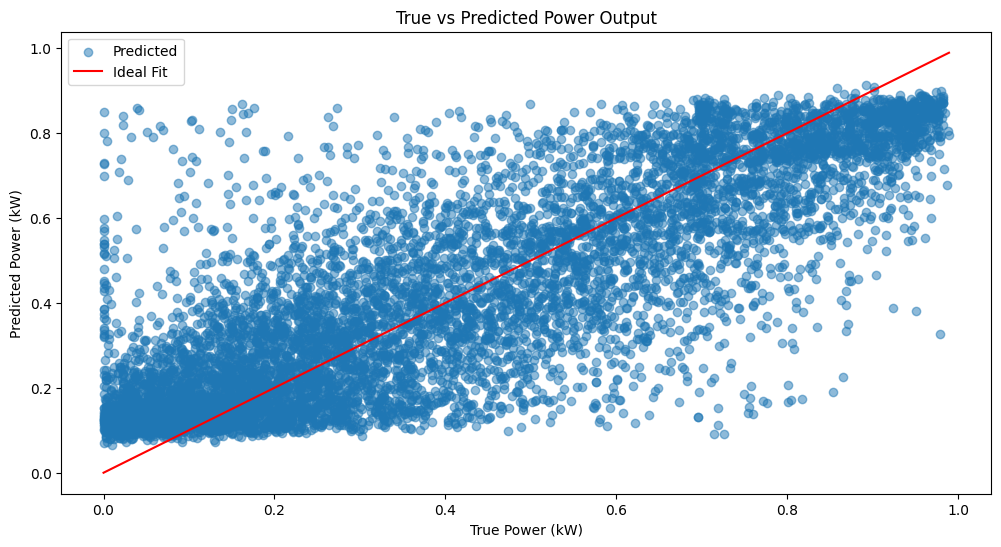

In [4]:
loss, mae, mse = model.evaluate(X_test_scaled, y_test_scaled)
print(f"Test Loss: {loss}, Test MAE: {mae}, Test MSE: {mse}")


y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)


results = pd.DataFrame({
    'True Power (kW)': y_test.values,
    'Predicted Power (kW)': y_pred.flatten()
})

plt.figure(figsize=(12, 6))
plt.scatter(results['True Power (kW)'], results['Predicted Power (kW)'], alpha=0.5, label='Predicted')
plt.plot([results['True Power (kW)'].min(), results['True Power (kW)'].max()],
         [results['True Power (kW)'].min(), results['True Power (kW)'].max()],
         color='red', label='Ideal Fit')
plt.title('True vs Predicted Power Output')
plt.xlabel('True Power (kW)')
plt.ylabel('Predicted Power (kW)')
plt.legend()
plt.show()

In [5]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
r2

0.6958632118405564